<PIL.TiffImagePlugin.TiffImageFile image mode=RGB size=2448x2048 at 0x7FE1D10DDC40>
(2048, 2448)


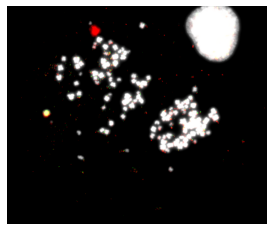

In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image_path = '/playpen-raid2/qinliu/data/ecDNA/Control/1_10.tif'
image = Image.open(image_path)


print(image)
image_gray = np.array(image)[:, :, 2]
print(image_gray.shape)

plt.imshow(image)
plt.axis('off')
plt.show()

In [10]:
from roifile import ImagejRoi as R

roi = R.fromfile('../docs/static/1_10.tif')[0]
print(roi)
print(len(roi.subpixel_coordinates))

ImagejRoi(
    roitype=ROI_TYPE.POINT,
    options=ROI_OPTIONS.PROMPT_BEFORE_DELETING | ROI_OPTIONS.SUB_PIXEL_RESOLUTION,
    version=228,
    top=20,
    left=140,
    bottom=1968,
    right=2033,
    n_coordinates=317,
    stroke_width=1,
    arrow_style_or_aspect_ratio=2,
    counters=numpy.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [2]:
import os
import numpy as np
from PIL import Image
import imageio
from roifile import ImagejRoi as R
from tqdm import tqdm


labels_folder = '/playpen-raid2/qinliu/data/ecDNA/labels'
images_folder = '/playpen-raid2/qinliu/data/ecDNA/images'
tiffs_folder = '/playpen-raid2/qinliu/data/ecDNA/FISH_Images/Training_set'
files = sorted(os.listdir(tiffs_folder))
for i in tqdm(range(len(files))):
    file  = files[i]
    file_path = os.path.join(tiffs_folder, file)

    # generate csv files
    try:
        raw_name = file.split('.')[0]
        coords = R.fromfile(file_path)[0].subpixel_coordinates
        np.save(f'{labels_folder}//{raw_name}.npy', coords)

        image_gray = np.array(Image.open(file_path))[:, :, 2]
        imageio.imwrite(f'{images_folder}//{raw_name}.png', image_gray)
    except:
        print('Missing annotation: ', file)

  0%|          | 0/3023 [00:00<?, ?it/s]

 14%|█▎        | 413/3023 [03:31<13:54,  3.13it/s]

Missing annotation:  NCIH2170_Antibiotics_DAPI_PS_51_Merge.tif
Missing annotation:  NCIH2170_Antibiotics_DAPI_PS_52_Merge.tif
Missing annotation:  NCIH2170_Antibiotics_DAPI_PS_53_Merge.tif


 32%|███▏      | 957/3023 [11:05<12:07,  2.84it/s]

Missing annotation:  NCIH2170_Control_2_33.tif
Missing annotation:  NCIH2170_Control_2_34.tif


...

 87%|████████▋ | 2633/3023 [28:46<02:37,  2.47it/s]

Missing annotation:  SUM159PT_DC_Control_57_Merge.tif


100%|█████████▉| 3015/3023 [32:03<00:03,  2.24it/s]

Missing annotation:  SUM159PT_DC_JQ1_72hr_93_Merge.tif


100%|██████████| 3023/3023 [32:07<00:00,  1.57it/s]


[  0   1   2   3   4   6   7   8   9  11  12  13  14  16  17  18  19  21
  22  23  24  26  27  28  29  31  32  33  34  36  37  38  39  41  42  43
  44  45  47  48  49  50  52  53  54  55  57  58  59  60  62  63  64  65
  67  68  69  70  72  73  74  75  77  78  79  80  82  83  84  85  86  88
  89  90  91  93  94  95  96  98  99 100 101 103 104 105 106 108 109 110
 111 113 114 115 116 118 119 120 121 123 124 125 126 128 129 130 131 132
 134 135 136 137 139 140 141 142 144 145 146 147 149 150 151 152 154 155
 156 157 159 160 161 162 164 165 166 167 169 170 171 172 173 175 176 177
 178 180 181 182 183 185 186 187 188 190 191 192 193 195 196 197 198 200
 201 202 203 205 206 207 208 210 211 212 213 214 216 217 218 219 221 222
 223 224 226 227 228 229 231 232 233 234 236 237 238 239 241 242 243 244
 246 247 248 249 251 252 253 255]
uint8


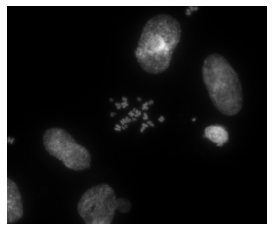

In [4]:
import matplotlib.pyplot as plt

print(np.unique(image_gray))
print(image_gray.dtype)

plt.imshow(image_gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [6]:
# generate landmark mask
import os
import numpy as np
from PIL import Image
import imageio
from roifile import ImagejRoi as R
import math
import matplotlib.pyplot as plt
from tqdm import tqdm


coords_folder = '/playpen-raid2/qinliu/data/ecDNA/labels'
masks_folder = '/playpen-raid2/qinliu/data/ecDNA/masks'
images_folder = '/playpen-raid2/qinliu/data/ecDNA/images'
files = sorted(os.listdir(images_folder))
r1, r2 = 3, 5 # inclusive
# for file in files:
for i in tqdm(range(len(files))):
    file = files[i]
    file_path = os.path.join(images_folder, file)

    # generate csv files
    raw_name = file.split('.')[0]
    image_npy = np.array(Image.open(file_path))

    mask_npy = np.zeros_like(image_npy)
    H, W = mask_npy.shape
    coords = np.load(f'{coords_folder}//{raw_name}.npy')
    for coord in coords:
        x, y = int(round(coord[0])), int(round(coord[1]))
        for i in range(-r2, r2 + 1):
            for j in range(-r2, r2 + 1):
                idx, idy = x + i, y + j
                if idx >= 0 and idx < W and idy >= 0 and idy < H:
                    dist = math.sqrt((idx - coord[0])**2 + (idy - coord[1])**2)
                    if dist <= r1:
                        mask_npy[idy, idx] = 255
                    elif dist <= r2:
                        if mask_npy[idy, idx] == 255:
                            pass
                        else:
                            mask_npy[idy, idx] = 128
                    else:
                        pass
                # else:
                #     print(raw_name, H, W, idx, idy)

    imageio.imwrite(f'{masks_folder}//{raw_name}.png', mask_npy)

100%|██████████| 2990/2990 [08:35<00:00,  5.80it/s]


In [2]:
import math
r1, r2 = 3, 5
for i in range(-r2, r2):
    for j in range(-r2, r2):
        print(math.sqrt(i*i + j*j))

7.0710678118654755
6.4031242374328485
5.830951894845301
5.385164807134504
5.0990195135927845
5.0
5.0990195135927845
5.385164807134504
5.830951894845301
6.4031242374328485
6.4031242374328485
5.656854249492381
5.0
4.47213595499958
4.123105625617661
4.0
4.123105625617661
4.47213595499958
5.0
5.656854249492381
5.830951894845301
5.0
4.242640687119285
3.605551275463989
3.1622776601683795
3.0
3.1622776601683795
3.605551275463989
4.242640687119285
5.0
5.385164807134504
4.47213595499958
3.605551275463989
2.8284271247461903
2.23606797749979
2.0
2.23606797749979
2.8284271247461903
3.605551275463989
4.47213595499958
5.0990195135927845
4.123105625617661
3.1622776601683795
2.23606797749979
1.4142135623730951
1.0
1.4142135623730951
2.23606797749979
3.1622776601683795
4.123105625617661
5.0
4.0
3.0
2.0
1.0
0.0
1.0
2.0
3.0
4.0
5.0990195135927845
4.123105625617661
3.1622776601683795
2.23606797749979
1.4142135623730951
1.0
1.4142135623730951
2.23606797749979
3.1622776601683795
4.123105625617661
5.38516480